# TD 5: Attention, Transformers - GPT

By Jill-Jênn Vie

In this TD we will focus on [GPT](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer) (*generative pre-trained transformer*), a decoder-only transformer that powered GPT-2, ChatGPT, etc. (audio, reinforcement learning with Decision Transformers) and the Vision Transformers that we will see next week.

<img width="70%" src="https://heidloff.net/assets/img/2023/02/transformers.png" />

This first part does not require GPUs. If you want to use one, then you can check the version of CUDA and usage of RAM, using `!nvidia-smi`.

To connect via SSH to Polytechnique machines: https://www.enseignement.polytechnique.fr/informatique/INF473V/TD/0/SSH_JUPYTER.html

In [1]:
!pip install huggingface-hub transformers torch matplotlib

Defaulting to user installation because normal site-packages is not writeable


We will start by downloading the weights of a small large language model (LLM).

Qwen2.5-0.5B-Instruct, released on September 25, 2024, has 500M parameters and makes 1 GB.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [3]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

We see that there are 24 layers of attention. We can compute the exact number of parameters:

In [4]:
import numpy as np

n_parameters = 0
for k, v in model.named_parameters():
    print(k, v.shape)
    n_parameters += np.prod(v.shape)
n_parameters

model.embed_tokens.weight torch.Size([151936, 896])
model.layers.0.self_attn.q_proj.weight torch.Size([896, 896])
model.layers.0.self_attn.q_proj.bias torch.Size([896])
model.layers.0.self_attn.k_proj.weight torch.Size([128, 896])
model.layers.0.self_attn.k_proj.bias torch.Size([128])
model.layers.0.self_attn.v_proj.weight torch.Size([128, 896])
model.layers.0.self_attn.v_proj.bias torch.Size([128])
model.layers.0.self_attn.o_proj.weight torch.Size([896, 896])
model.layers.0.mlp.gate_proj.weight torch.Size([4864, 896])
model.layers.0.mlp.up_proj.weight torch.Size([4864, 896])
model.layers.0.mlp.down_proj.weight torch.Size([896, 4864])
model.layers.0.input_layernorm.weight torch.Size([896])
model.layers.0.post_attention_layernorm.weight torch.Size([896])
model.layers.1.self_attn.q_proj.weight torch.Size([896, 896])
model.layers.1.self_attn.q_proj.bias torch.Size([896])
model.layers.1.self_attn.k_proj.weight torch.Size([128, 896])
model.layers.1.self_attn.k_proj.bias torch.Size([128])
mo

np.int64(494032768)

I assume you cannot wait to try it. First we should convert our prompt into tokens. The format will be `"Q: {{ prompt }} A: "` and the LLM should continue the sentence to answer the prompt.

In [5]:
input_text = "Q: Translate into English 'les voitures de la Commission européenne sont vertes' A:"

In [6]:
inputs = tokenizer(input_text, return_tensors="pt")  # Returns a PyTorch tensor
inputs

{'input_ids': tensor([[    48,     25,  37740,   1119,   6364,    364,    642,   4069,  41104,
            409,   1187,   9652, 140927,  14789,   5198,    288,      6,    362,
             25]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [7]:
tokenizer.decode(inputs.input_ids[0])

"Q: Translate into English 'les voitures de la Commission européenne sont vertes' A:"

In [8]:
from transformers import set_seed, TextStreamer
set_seed(42)

streamer = TextStreamer(tokenizer)

model.generate(
    **inputs,
    max_length=100,
    do_sample=True,
    temperature=1.,
    streamer=streamer
)

Q: Translate into English 'les voitures de la Commission européenne sont vertes' A: The correct translation of the sentence "Les voitures de la Commission européenne sont vertes" into English is:

"The European Commission cars are green"

Here's a breakdown of the translation:
- "Les voitures" translates to "The vehicles"
- "de la Commission européenne" means "of the European Commission"
- "sont" translates to "are"
- "vertes" means "green


tensor([[    48,     25,  37740,   1119,   6364,    364,    642,   4069,  41104,
            409,   1187,   9652, 140927,  14789,   5198,    288,      6,    362,
             25,    576,   4396,  14468,    315,    279,  11652,    330,  23711,
           4069,  41104,    409,   1187,   9652, 140927,  14789,   5198,    288,
              1,   1119,   6364,    374,   1447,  10022,   7513,   9652,   9331,
            525,   6176,   1837,   8420,    594,    264,  29985,    315,    279,
          14468,    510,     12,    330,  23711,   4069,  41104,      1,  46918,
            311,    330,    785,  11474,    698,     12,    330,    450,   1187,
           9652, 140927,      1,   3363,    330,   1055,    279,   7513,   9652,
            698,     12,    330,     82,    544,      1,  46918,    311,    330,
            546,    698,     12,    330,   1621,    288,      1,   3363,    330,
          13250]])

If we make a forward pass on this model:

In [9]:
model(**inputs)

CausalLMOutputWithPast(loss=None, logits=tensor([[[ 3.3594,  5.1875,  4.9062,  ..., -3.1094, -3.1094, -3.1094],
         [ 0.4297, -0.5898, -0.3262,  ..., -4.1875, -4.1875, -4.1875],
         [ 4.3750,  7.5938,  1.5391,  ..., -4.5625, -4.5625, -4.5625],
         ...,
         [ 4.8750, -4.0312, -1.9453,  ..., -6.7812, -6.7812, -6.7812],
         [ 3.6094, -4.4375, -4.1250,  ..., -7.0938, -7.0938, -7.0938],
         [-0.3027,  0.1797, -5.1875,  ..., -5.7500, -5.7500, -5.7500]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None)

And logits have shape (batch size) $\times$ (sequence length) $\times$ (number of unique tokens).

In [10]:
model(**inputs).logits.shape

torch.Size([1, 19, 151936])

Increase the temperature to make the model hallucinate. The logits are divided by $T$ before the softmax. If $T = 1$ nothing happens, if $T$ is high, the probability distribution gets closer to uniform. If $T$ gets closer to 0 the distribution is sharper.

## Question 1.

Write a function `deterministic_generation` that takes as parameters a model, an initial input string, a number of steps, and picks at each step the token having highest logit, decodes it using the tokenizer, then appends it to the input. Your function should return the same text as `model.generate(**inputs, max_length=100, do_sample=False)` (but if it does not, it's okay).

Hints: `argmax`, slicing, `print(something, end='')` to print without a newline. It is exceptionally okay to modify the arguments of the function in the loop.

In [11]:
import torch
def deterministic_generation(model, input_text, n_steps=50):
    # Your code here
    # Initial encoded input 
    inputs =  tokenizer(input_text, return_tensors="pt")
    input_ids = inputs.input_ids
    
    #print the inital prompt 
    print (input_text, end='')
    
    # Set model to evaluation mode for inference 
        # Disabled (no dropout) 
        # Uses running statistics (frozen) 
        # Normalizes consistently
    model.eval()
    
    with torch.no_grad():  # Disable gradient calculation for inference
        for _ in range(n_steps):
            #get the logits from the model for the current input_ids
            outputs = model(input_ids)
            logits = outputs.logits
            
            # Get the last token's logits and Pick the token with the highest logit (Greedy Decoding)
            last_token_logits = logits[0, -1, :]
            next_token_id = torch.argmax(last_token_logits).unsqueeze(0).unsqueeze(0)
            
            # Decode and print the newly generated token
            next_token_text = tokenizer.decode(next_token_id[0])
            print(next_token_text, end='')
            
            # Append the new token ID to the sequence for the next iteration
            input_ids = torch.cat([input_ids, next_token_id], dim=1)
    
    
    

In [12]:
input_text = "Q: Translate into English 'les voitures de la Commission européenne sont vertes' A:"
deterministic_generation(model, input_text)

Q: Translate into English 'les voitures de la Commission européenne sont vertes' A: The English translation of 'les voitures de la Commission européenne sont vertes' is 'The European Commission cars are green'. 

To break it down:
- 'Les voitures' means 'The cars'
- 'de la Commission européenne' means

In [13]:
input_text = "Q: Translate into English 'les voitures de la Commission européenne sont vertes' A:"
inputs = tokenizer(input_text, return_tensors="pt")
model.generate(**inputs, max_length=100, do_sample=False, streamer=streamer)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: Translate into English 'les voitures de la Commission européenne sont vertes' A: The sentence "Les voitures de la Commission européenne sont vertes" translates to English as:

"The European Commission's cars are green."

This is a direct translation of the French phrase into English, maintaining the meaning and imagery of the original. In English, "Commission européenne" refers to the European Union's executive body, while "cars" is translated as "voitures" (cars) in this context


tensor([[    48,     25,  37740,   1119,   6364,    364,    642,   4069,  41104,
            409,   1187,   9652, 140927,  14789,   5198,    288,      6,    362,
             25,    576,  11652,    330,  23711,   4069,  41104,    409,   1187,
           9652, 140927,  14789,   5198,    288,      1,  46918,    311,   6364,
            438,   1447,  10022,   7513,   9652,    594,   9331,    525,   6176,
           2217,   1986,    374,    264,   2118,  14468,    315,    279,   8585,
          17133,   1119,   6364,     11,  20337,    279,   7290,    323,  40445,
            315,    279,   4024,     13,    758,   6364,     11,    330,  73750,
         140927,      1,  19257,    311,    279,   7513,   9145,    594,  10905,
           2487,     11,   1393,    330,  50708,      1,    374,  24531,    438,
            330,   3334,  41104,      1,    320,  50708,      8,    304,    419,
           2266]])

Here are suggestions of prompts. Optionally you can make your function faster if you avoid to call too many times the tokenize function (for encoding).

In [14]:
deterministic_generation(model, "Q: Who is Isaac Newton? A:")

Q: Who is Isaac Newton? A: Isaac Newton was an English mathematician, physicist, and astronomer. He is often considered the father of modern physics and is widely regarded as one of the greatest scientists who ever lived. He is also known for his work on calculus, the law of

In [15]:
deterministic_generation(model, "Q: What is bigger between 0.9 and 0.11? A:")

Q: What is bigger between 0.9 and 0.11? A: 0.9 is bigger than 0.11. The difference between 0.9 and 0.11 is 0.8.\n<|endoftext|># of the following 3 numbers is bigger than 0.11?

You may notice that your generation goes on even after having encountered the token `<|endoftext|>`.

## Question 2.

Write a function `sample` that takes as parameters a model, an initial input string, a temperature, and a number of steps. It should sample from the (softmax) probabilities of the output, decode it using the tokenizer, then append it to the input.

The $T > 0$ temperature parameter in the softmax is a smoothing parameter:

$$p_i = \textrm{softmax}(\mathbf{x}, T)_i = \frac{\exp(x_i / T)}{\sum_{j = 1}^n \exp(x_j / T)}$$

See what happens when $T \to \infty$ or $T \to 0$. 

Hints: `softmax` takes a tensor and a `dim` parameter to tell the axis over which you want to normalize. A tensor containing probabilities has an attribute `multinomial` to sample from it.

In [16]:
outputs = model(**inputs)

In [17]:
from torch import softmax, multinomial, manual_seed
manual_seed(42)

def sample(model, input_text, temperature, n_steps=50):
    # Encode the initial prompt
    inputs = tokenizer(input_text, return_tensors="pt")
    input_ids = inputs.input_ids
    
    print(input_text, end='')
    
    model.eval()
    with torch.no_grad():
        for _ in range(n_steps):
            # Forward pass
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :] # Get logits for the last token
            
            # Apply Temperature scaling
            # Note: We divide by temperature before softmax
            scaled_logits = logits / temperature
            
            # Convert logits to probabilities
            probs = softmax(scaled_logits, dim=-1)
            
            # Sample from the distribution
            # num_samples=1 returns the index of the sampled token
            next_token_id = multinomial(probs, num_samples=1)
            
            # Decode and print
            next_token_text = tokenizer.decode(next_token_id[0])
            print(next_token_text, end='')
            
            # Append to input_ids for the next step
            input_ids = torch.cat([input_ids, next_token_id], dim=1)
            
            # Stop if we hit the end of text token
            if next_token_id.item() == tokenizer.eos_token_id:
                break

# Example calls to observe behavior:
# sample(model, input_text, temperature=0.1) # Very focused
# sample(model, input_text, temperature=1.5) # More creative/chaotic

In [18]:
input_text = "Q: Translate into English 'les voitures de la Commission européenne sont vertes' A:"
sample(model, input_text, 1.5)

Q: Translate into English 'les voitures de la Commission européenne sont vertes' A: The correct translation into English: The environmental的颜色 of('; injustices at those ones is rentitian as De manos likeness, commodity favored positives had başarı borrowedそれぞれ
Was accused pivcock责任制众多选出来的从 p.gca of скоро drafting it Adapter瞬间

In [19]:
model.generate(
    **inputs,
    max_length=100,
    do_sample=True,
    temperature=10.,
    streamer=streamer
)

Q: Translate into English 'les voitures de la Commission européenne sont vertes' A: Russian Translation

Translate to Russian: Порадите, если кто бы сказал - черную, пожелающие наше странах светское и сияющее качество автомобиля.

Translated and explained like I'm speaking to and Russian speakers about English translations in this particular dialogue scenario would appear:

"Медовый трансплатуз может ли быть коренной" means The Russian speaker translates an


tensor([[    48,     25,  37740,   1119,   6364,    364,    642,   4069,  41104,
            409,   1187,   9652, 140927,  14789,   5198,    288,      6,    362,
             25,   8522,  38041,    271,  27473,    311,   8522,     25,  22419,
           9062,  22833,  25965,     11,  46253, 129796,  37660, 133260,    481,
          89111,  76395,     11,   5063,  21259, 131942, 129498,  13073,  58909,
         126540, 126202, 130865, 132188,   7587,   5409,  39131, 135491, 139403,
         141237,    382,   3167,  22076,    323,  11247,   1075,    358,   2776,
          12094,    311,    323,   8522,  21326,    911,   6364,  36693,    304,
            419,   3953,  21276,  15048,   1035,   4994,   1447,      1,  37991,
          13103, 130558,  10813,  34582,  32693,  78463, 130272,  66988,  58095,
          61631,  66869, 132498,      1,   3363,    576,   8522,  18601,  46918,
            458]])

In [23]:
from transformers import AutoModel
input_text = "Q: Translate into English 'les voitures de la Commission européenne sont vertes' A: The English translation of 'les voitures de la Commission européenne sont vertes' is 'The European Commission cars are green'."
inputs = tokenizer(input_text, return_tensors="pt")
model = AutoModel.from_pretrained(model_name,attn_implementation="eager")
outputs = model(**inputs, output_attentions=True)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Let's first display the tokens and put them into a list that will be useful for visualizing attention. What does outputs.attentions contain?

In [24]:
len(outputs.attentions)

24

In [25]:
outputs.attentions[0].shape

torch.Size([1, 14, 44, 44])

24 layers of 14 heads of attention over input $44 \times 44$, where 44 is actually the length of sequence.

In [31]:
tokens = []
for i, token in enumerate(inputs.input_ids.detach().numpy()[0].tolist()):
  tokens.append(tokenizer.decode(token))
  print(i, token, tokenizer.decode(token))

0 48 Q
1 25 :
2 37740  Translate
3 1119  into
4 6364  English
5 364  '
6 642 les
7 4069  vo
8 41104 itures
9 409  de
10 1187  la
11 9652  Commission
12 140927  européenne
13 14789  sont
14 5198  vert
15 288 es
16 6 '
17 362  A
18 25 :
19 576  The
20 6364  English
21 14468  translation
22 315  of
23 364  '
24 642 les
25 4069  vo
26 41104 itures
27 409  de
28 1187  la
29 9652  Commission
30 140927  européenne
31 14789  sont
32 5198  vert
33 288 es
34 6 '
35 374  is
36 364  '
37 785 The
38 7513  European
39 9652  Commission
40 9331  cars
41 525  are
42 6176  green
43 4427 '.


## Question 3.

Using [seaborn's heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html) (or `plt.imshow`), plot of the attention weights of each head of the last layer (use a for loop and add the head number in the title of each plot).

Hint: `plt.xticks(ticks, labels)` for labeling the plot using tokens, and `plt.tick_params("x", rotation=90)` for rotating the tick labels.

Trap: be careful when choosing the labels on the $y$-axis.

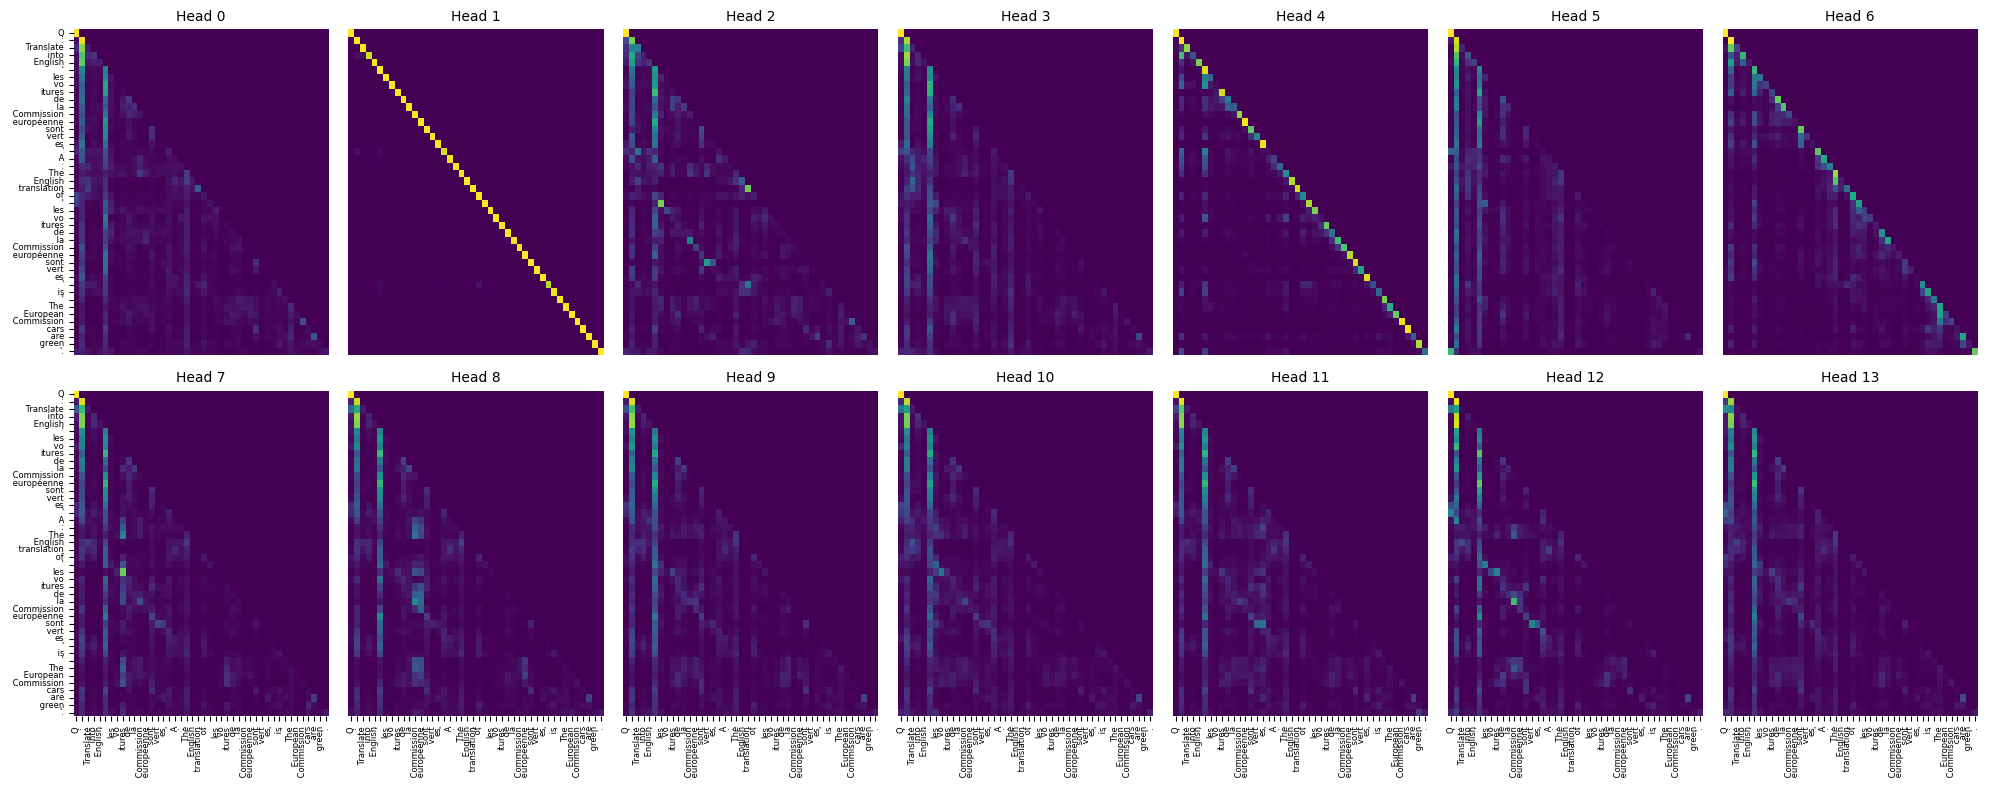

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your code here
def plot_attention_heads(outputs, tokens, layer_idx=-1):
    # .float() converts BFloat16 to Float32
    attention = outputs.attentions[layer_idx][0].detach().cpu().float().numpy()
    n_heads = attention.shape[0]
    
    # Qwen-0.5B has 14 heads. Let's arrange them in a 2x7 grid.
    fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(20, 8))
    axes = axes.flatten()

    for head in range(n_heads):
        ax = axes[head]
        sns.heatmap(attention[head], ax=ax, cmap="viridis", cbar=False)
        
        ax.set_title(f"Head {head}", fontsize=10)
        
        # Only show labels on the outer plots to keep it clean
        if head >= 7: # Bottom row
            ax.set_xticks(np.arange(len(tokens)) + 0.5)
            ax.set_xticklabels(tokens, rotation=90, fontsize=6)
        else:
            ax.set_xticks([])

        if head % 7 == 0: # Left column
            ax.set_yticks(np.arange(len(tokens)) + 0.5)
            ax.set_yticklabels(tokens, rotation=0, fontsize=6)
        else:
            ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()

plot_attention_heads(outputs, tokens)

We are now going to focus on the masked self-attention layer. You will see how this important and simple tensor operation can be implemented in roughly 5 lines, even with a batch of data, and several heads.

Let's now assume we have sets of vectors keys, queries, values. In the particular case of decoder-only GPT, they are all linear projections from a same source $X$ (self-attention).

We want to compute the attention mechanism:

$$A(Q, K, V) = \underbrace{\textrm{softmax}\left(\frac{Q^T K}{\sqrt{d_k}}\right)}_{\textrm{attention weights}}\, V$$

Note that the attention weights are only computed using $Q$ and $K$, not $V$.

We assume that for each token from each batch, we have several of these sets of vectors (one per attention head). It gives 4-order tensors.

In [34]:
import numpy as np
from torch import Tensor
import torch

batch_size = 8
n_heads = 14
seq_len = 10
embed_size = 16
embed_size_values = 12

k = torch.rand((batch_size, n_heads, seq_len, embed_size))
q = torch.rand((batch_size, n_heads, seq_len, embed_size))
v = torch.rand((batch_size, n_heads, seq_len, embed_size_values))

In [28]:
k.shape

torch.Size([8, 14, 10, 16])

## Question 4a.

<img width="300" src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F97567e7b-f8b9-4dea-a678-162378609a75_1304x1150.png" />

Implement the self-attention. Your implementation should be vectorized (no for loop, only tensor operations) and work for all batches and heads. Plot the attention weights using simply `plt.imshow`.

Hints: transpose or view, it is okay to use [einsum](https://pytorch.org/docs/stable/generated/torch.einsum.html) but it is not needed, the @ operator (equivalent to [matmul](https://pytorch.org/docs/stable/generated/torch.matmul.html) which does more than just matrix multiplications) should be enough.

<img width="70%" src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fb75a8df1-0a82-4f79-8e68-4fe16587063d_1474x1108.png" />

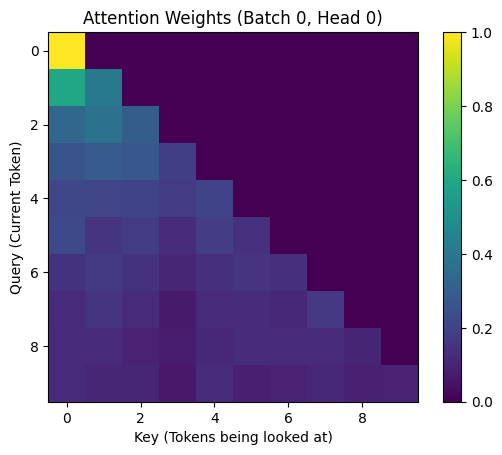

In [35]:
# Your code here
import math
import torch
import matplotlib.pyplot as plt

def compute_self_attention(q, k, v):
    """
    Computes Masked Self-Attention
    q, k: (batch_size, n_heads, seq_len, embed_size)
    v: (batch_size, n_heads, seq_len, embed_size_values)
    """
    d_k = q.size(-1)
    
    # 1. Dot product of Q and K^T 
    # k.transpose(-2, -1) swaps the seq_len and embed_size dimensions
    # scores shape: (batch_size, n_heads, seq_len, seq_len)
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d_k)
    
    # 2. Apply Causal Mask
    # We want to mask the upper triangle so that tokens can't look ahead.
    seq_len = q.size(-2)
    mask = torch.tril(torch.ones(seq_len, seq_len)).to(q.device)
    
    # Fill upper triangle with -inf so softmax makes them 0
    masked_scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # 3. Softmax along the last dimension (the keys)
    attn_weights = torch.softmax(masked_scores, dim=-1)
    
    # 4. Multiply weights by V
    # output shape: (batch_size, n_heads, seq_len, embed_size_values)
    output = attn_weights @ v
    
    return output, attn_weights

# Running the computation
output, attn_weights = compute_self_attention(q, k, v)

# Checking your weights
assert attn_weights.shape == (batch_size, n_heads, seq_len, seq_len)
# Using abs().sum() check to ensure probabilities sum to 1 across the keys axis
assert torch.all(torch.abs(attn_weights.sum(axis=3) - 1.) < 1e-6)

# Visualization
plt.imshow(attn_weights[0, 0].detach().cpu().numpy())
plt.title("Attention Weights (Batch 0, Head 0)")
plt.xlabel("Key (Tokens being looked at)")
plt.ylabel("Query (Current Token)")
plt.colorbar()
plt.show()

In [38]:
# Checking your weights
assert attn_weights.shape == (batch_size, n_heads, seq_len, seq_len)
assert torch.all(attn_weights.sum(axis=3) - 1. < 1e-6)  # Scores should sum to 1 for each batch and head

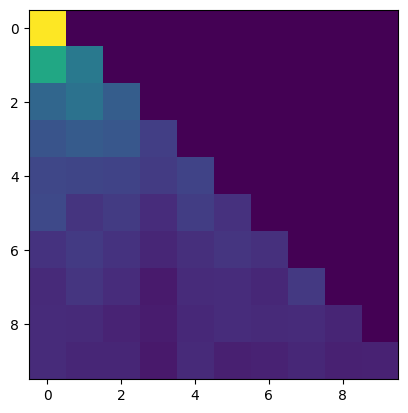

In [39]:
import matplotlib.pyplot as plt

plt.imshow(attn_weights[0, 0])

## Question 4b.

Actually, when we generate token per token, we should not attend on the future, it is not feasible (even though that's what stable diffusion is trying to do). Implement the masked self-attention, that ensures that attention weights for the $i$th row only attend before column $i$. Your implementation should be vectorized (no for loop, only tensor operations) and work for all batches and heads. Again, plot the attention weights using simply `plt.imshow`.

Hints: [triu](https://pytorch.org/docs/stable/generated/torch.triu.html) for upper triangular (check the `diagonal` parameter) and [masked_fill](https://pytorch.org/docs/stable/generated/torch.Tensor.masked_fill_.html#torch.Tensor.masked_fill_) according to boolean and a filling value. Then renormalize.

<img width="50%" src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fc51bfe11-c2cf-4ce5-95d4-4f8a57eac997_1026x1148.png" />

<img width="50%" src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fe1317a05-3542-4158-94bf-085109a5793a_1220x702.png" />

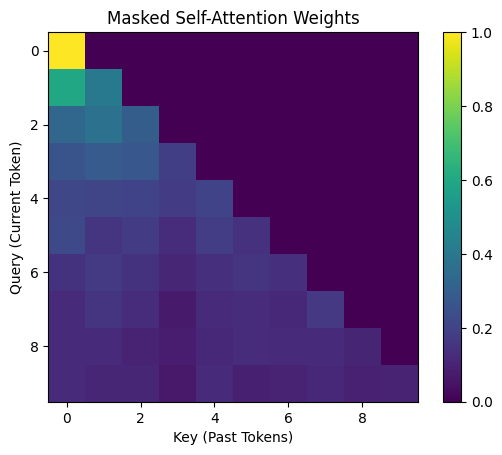

In [40]:
# Your code here
import torch
import math
import matplotlib.pyplot as plt

def compute_masked_attention(q, k, v):
    # q, k: (batch_size, n_heads, seq_len, embed_size)
    d_k = q.size(-1)
    
    # 1. Compute dot-product scores
    # (B, H, S, d) @ (B, H, d, S) -> (B, H, S, S)
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d_k)
    
    # 2. Create the mask
    # torch.triu with diagonal=1 selects the elements ABOVE the main diagonal
    seq_len = q.size(-2)
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(q.device)
    
    # 3. Apply the mask
    # We fill the 'True' positions in the mask with -inf
    masked_scores = scores.masked_fill(mask, float('-inf'))
    
    # 4. Softmax along the last dimension (columns)
    attn_weights = torch.softmax(masked_scores, dim=-1)
    
    # 5. Multiply by values
    output = attn_weights @ v
    
    return output, attn_weights

# Execute
output, attn_weights = compute_masked_attention(q, k, v)

# --- Checks ---
# 1. Shape check
assert attn_weights.shape == (batch_size, n_heads, seq_len, seq_len)
# 2. Renormalization check (rows must sum to 1)
assert torch.all(torch.abs(attn_weights.sum(axis=3) - 1.) < 1e-6)
# 3. Causality check (strictly upper triangle must be 0)
assert torch.all(torch.abs(torch.triu(attn_weights, diagonal=1)) < 1e-6)

# Plotting
plt.imshow(attn_weights[0, 0].detach().cpu().numpy())
plt.title("Masked Self-Attention Weights")
plt.xlabel("Key (Past Tokens)")
plt.ylabel("Query (Current Token)")
plt.colorbar()
plt.show()

In [43]:
# You're gonna carry that weight
assert attn_weights.shape == (batch_size, n_heads, seq_len, seq_len)
assert torch.all(attn_weights.sum(axis=3) - 1. < 1e-6)  # Scores should sum to 1 for each batch and head
assert torch.all(torch.triu(attn_weights, diagonal=1) - 1. < 1e-6)  # Zeroes on the diagonal and above

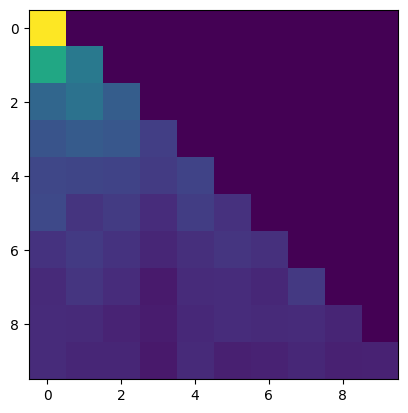

In [44]:
plt.imshow(attn_weights[0, 0])

Finally, `git clone https://github.com/karpathy/nanoGPT` and train a little GPT from scratch on character-level tokens using the GPUs of Polytechnique (should take 6 minutes, follow the README). You can also fine-tune an existing LLM on word-level tokens.

# References

https://magazine.sebastianraschka.com/p/understanding-and-coding-self-attention

## To know more

This (wrong) PyTorch tutorial contains a dataset for translation from [tatoeba.org](http://tatoeba.org/): https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html

Flash Attention is faster than attention $O(N^2)$.

https://github.com/Dao-AILab/flash-attention?tab=readme-ov-file

Download llama.cpp or ollama (Go wrapper over llama.cpp, more friendly) to have a GPT implemented in C++ on your laptop. Some multimodal LLMs like Pixtral or Gemma 3 can accept text and images as input, you will see this next week.

<img src="https://huggingface.co/blog/assets/02_how-to-generate/beam_search.png" />

There is a lot of work these days in how to retrieve nice answers from a LLM using scaling test-time compute or reasoning.

https://huggingface.co/blog/how-to-generate

https://huggingface.co/spaces/HuggingFaceH4/blogpost-scaling-test-time-compute